In [2]:
#Importation des bibliotheques
import numpy as np
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
  


In [3]:
#Importation du jeu de données load_digits
mnist=datasets.load_digits()
#Séparation entrainement/test 
(x_train,x_test,y_train,y_test)=train_test_split(mnist.data,mnist.target,test_size=0.25)
#voir la taille de x_train et x_test
print(len(x_train))
print(len(x_test))

1347
450


In [4]:
#Entrainement du modele
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [5]:
#Prédiction et affichage des accuracy_score et du rapport de classification pour k=3
y_pred=knn.predict(x_test)
print("Accuracy:")
print(accuracy_score(y_test,y_pred))
print("Classification Report:")
print(classification_report(y_test,y_pred))


Accuracy:
0.9822222222222222
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.96      0.98      0.97        45
           2       1.00      1.00      1.00        41
           3       0.96      1.00      0.98        54
           4       1.00      1.00      1.00        39
           5       0.95      0.98      0.96        41
           6       0.98      1.00      0.99        47
           7       1.00      0.98      0.99        43
           8       1.00      0.96      0.98        51
           9       0.98      0.93      0.95        44

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



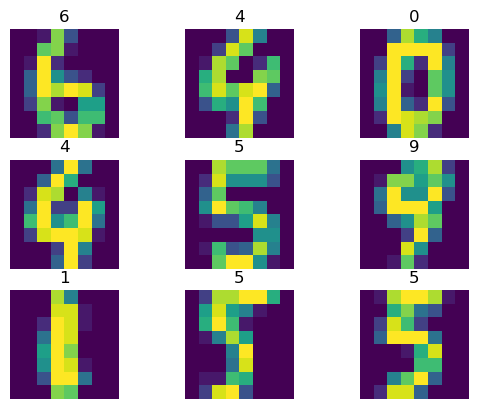

In [6]:
#Visualisation
plt.figure
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(8,8))
    plt.title(y_train[i])
    plt.axis('off')
    plt.savefig('mnist_plot.png')

k=3 , accuracy_score=97.78% 
k=5 , accuracy_score=97.22% 
k=7 , accuracy_score=97.22% 
k=9 , accuracy_score=97.22% 
k=11 , accuracy_score=97.22% 
k=13 , accuracy_score=96.67% 
k=15 , accuracy_score=97.22% 
k=17 , accuracy_score=96.67% 
k=19 , accuracy_score=96.11% 
Highest_accuracy: 0.9777777777777777
Best_k: 3


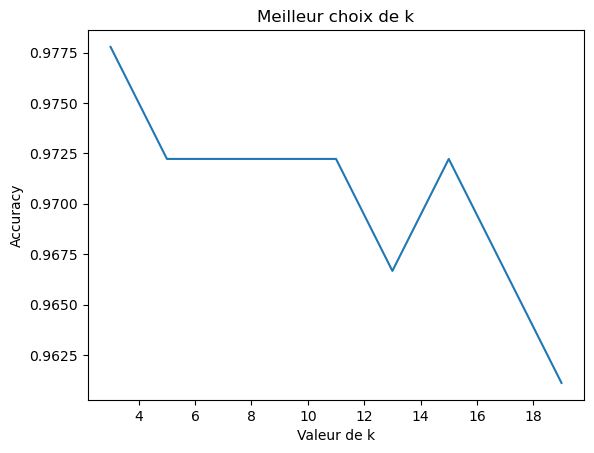

In [11]:
#tester d'autres valeurs de k
k_values=range(3,20,2)
accuracies=[]
accuracies1=[]
#choisir 10% des données pour le test
(x_train,x_val,y_train,y_val)=train_test_split(mnist.data,mnist.target,test_size=0.1)
#parcourir les valeurs de k
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    y_pred=model.predict(x_val)
    score1=accuracy_score(y_val,y_pred)
    #score2=model.score(x_val,y_val) meme chose mais la fonction est interne la prediction se fait a l'interieur
    print("k=%d , accuracy_score=%.2f%% "%(k,score1 *100))
    accuracies.append(score1)
    #accuracies1.append(score2)
#for i in accuracies1:
    #print(i*100)
i=np.argmax(accuracies)
print("Highest_accuracy:",accuracies[i])
print("Best_k:",k_values[i])
#Methode 2 à l'aide d'un plot
plt.plot(k_values,accuracies)
plt.xlabel("Valeur de k")
plt.ylabel("Accuracy")
plt.title("Meilleur choix de k")
plt.show()
    

Accuracy: 0.9755555555555555
Rapport de classification:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       0.88      1.00      0.94        38
           2       0.98      0.96      0.97        47
           3       1.00      1.00      1.00        47
           4       1.00      0.97      0.99        36
           5       0.98      0.98      0.98        45
           6       1.00      1.00      1.00        47
           7       0.98      1.00      0.99        57
           8       0.97      0.85      0.91        40
           9       0.98      0.98      0.98        48

    accuracy                           0.98       450
   macro avg       0.98      0.97      0.97       450
weighted avg       0.98      0.98      0.98       450



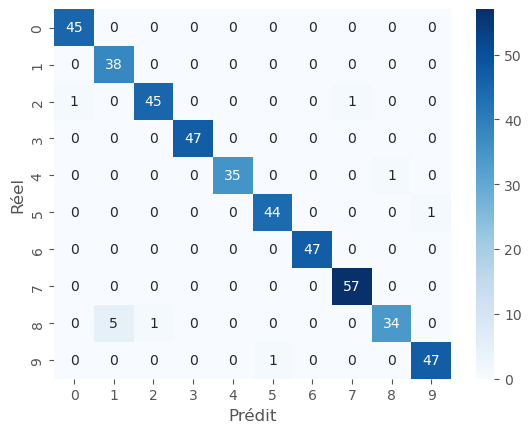

In [126]:
#Maintenant qu'on a la meilleure valeur de k on peut entrainer le modele selon cette valeur
knn=KNeighborsClassifier(n_neighbors=k_values[i])
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Rapport de classification:")
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()



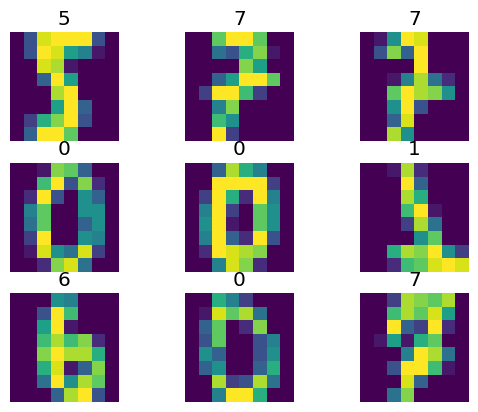

In [115]:
#On visualise
plt.figure
for i in range(0,9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i].reshape(8,8))
    plt.title(y_pred[i])
    plt.axis('off')
    plt.savefig('mnist_predit.png')
plt.show()
    

In [116]:
errors=[1-acc for acc in accuracies]
print(errors)

[0.005555555555555536, 0.005555555555555536, 0.011111111111111072, 0.01666666666666672, 0.01666666666666672, 0.022222222222222254, 0.022222222222222254, 0.02777777777777779, 0.02777777777777779]


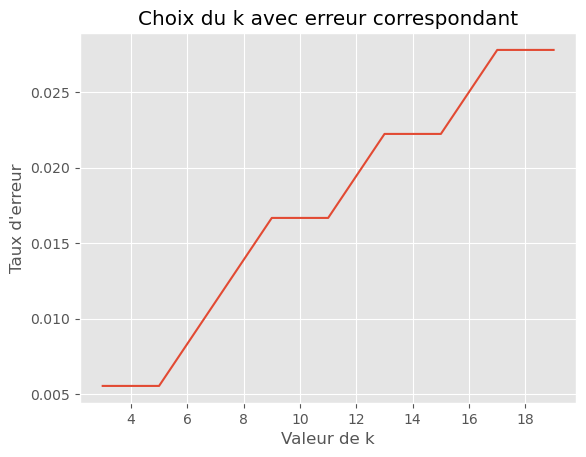

In [117]:
plt.figure(dpi=100)
plt.style.use('ggplot')
plt.plot(k_values,errors)
plt.xlabel("Valeur de k")
plt.ylabel("Taux d'erreur")
plt.title("Choix du k avec erreur correspondant")
plt.show()

